<a href="https://colab.research.google.com/github/rfpmaa/uas-ml/blob/main/notebook/UAS_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
import pandas as pd

url = "https://raw.githubusercontent.com/rfpmaa/uas-ml/main/dataset/beasiswa.csv"

df = pd.read_csv(url)
df.head()

,IPK,Semester,Penghasilan_Ortu,Tanggungan_Keluarga,Prestasi,Aktif_Organisasi,Status_Rumah,Jenis_Kelamin,Diterima_Beasiswa
0,3.37,2,2000000,3,Internasional,Tidak,Milik Sendiri,P,0
1,3.15,5,4000000,6,Tidak Ada,Ya,Kos/Asrama,P,1
2,3.43,3,1500000,6,Provinsi,Ya,Kontrak,P,1
3,3.73,6,1000000,5,Tidak Ada,Tidak,Milik Sendiri,L,1
4,3.12,2,500000,1,Tidak Ada,Tidak,Milik Sendiri,P,1


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   IPK                  300 non-null    float64
 1   Semester             300 non-null    int64  
 2   Penghasilan_Ortu     300 non-null    int64  
 3   Tanggungan_Keluarga  300 non-null    int64  
 4   Prestasi             300 non-null    object 
 5   Aktif_Organisasi     300 non-null    object 
 6   Status_Rumah         300 non-null    object 
 7   Jenis_Kelamin        300 non-null    object 
 8   Diterima_Beasiswa    300 non-null    int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 21.2+ KB


In [17]:
df.isnull().sum()

,0
IPK,0
Semester,0
Penghasilan_Ortu,0
Tanggungan_Keluarga,0
Prestasi,0
Aktif_Organisasi,0
Status_Rumah,0
Jenis_Kelamin,0
Diterima_Beasiswa,0


In [18]:
df.describe()

,IPK,Semester,Penghasilan_Ortu,Tanggungan_Keluarga,Diterima_Beasiswa
count,300.000000,300.000000,3.000000e+02,300.000000,300.000000
mean,3.195400,4.906667,2.065000e+06,3.396667,0.706667
std,0.336704,1.999487,1.283393e+06,1.701658,0.456051
min,2.070000,2.000000,5.000000e+05,1.000000,0.000000
25%,2.960000,3.000000,1.000000e+06,2.000000,0.000000
50%,3.220000,5.000000,1.500000e+06,3.000000,1.000000
75%,3.420000,6.000000,3.000000e+06,5.000000,1.000000
max,4.000000,8.000000,6.000000e+06,6.000000,1.000000


In [19]:
df["Diterima_Beasiswa"].value_counts()

,count
Diterima_Beasiswa,
1,212
0,88


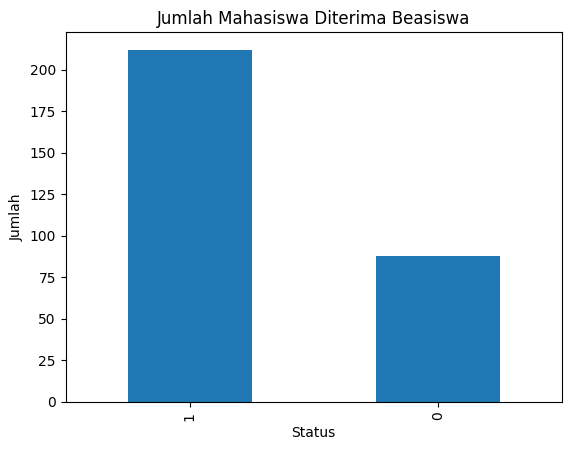

In [20]:
import matplotlib.pyplot as plt

df["Diterima_Beasiswa"].value_counts().plot(kind="bar")

plt.title("Jumlah Mahasiswa Diterima Beasiswa")
plt.xlabel("Status")
plt.ylabel("Jumlah")

plt.show()

In [21]:
df.dtypes

,0
IPK,float64
Semester,int64
Penghasilan_Ortu,int64
Tanggungan_Keluarga,int64
Prestasi,object
Aktif_Organisasi,object
Status_Rumah,object
Jenis_Kelamin,object
Diterima_Beasiswa,int64


In [22]:
from sklearn.preprocessing import LabelEncoder

# Membuat salinan dataset
df_encode = df.copy()

# Membuat objek LabelEncoder
le = LabelEncoder()

# Mengubah semua kolom bertipe object menjadi angka
for col in df_encode.select_dtypes(include='object').columns:
    df_encode[col] = le.fit_transform(df_encode[col])

# Menampilkan 5 data pertama
df_encode.head()

,IPK,Semester,Penghasilan_Ortu,Tanggungan_Keluarga,Prestasi,Aktif_Organisasi,Status_Rumah,Jenis_Kelamin,Diterima_Beasiswa
0,3.37,2,2000000,3,0,0,3,1,0
1,3.15,5,4000000,6,4,1,1,1,1
2,3.43,3,1500000,6,3,1,0,1,1
3,3.73,6,1000000,5,4,0,3,0,1
4,3.12,2,500000,1,4,0,3,1,1


In [23]:
# X = fitur (input)
X = df_encode.drop("Diterima_Beasiswa", axis=1)

# y = target
y = df_encode["Diterima_Beasiswa"]

print("Jumlah fitur:", X.shape)
print("Jumlah target:", y.shape)

Jumlah fitur: (300, 8)
Jumlah target: (300,)


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Data Train :", X_train.shape)
print("Data Test  :", X_test.shape)

Data Train : (240, 8)
Data Test  : (60, 8)
